# 🧠 Customer Churn Prediction — Logistic Regression
> **Pipeline:** LabelEncoder → StandardScaler → LogisticRegression → joblib  
> **Dataset:** Customer_Churn.xls (2,000 customers, 11 features)  
> **Result:** Logistic Regression BEATS Random Forest on this dataset — see Section 10 for proof.

## 1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✅ Libraries loaded!')

✅ Libraries loaded!


## 2. Load & Explore Data

In [16]:
df = pd.read_excel("Customer_Churn.xls")
df.drop(columns=['Unnamed: 0', 'CustomerID'], inplace=True)

print(f'Shape: {df.shape}')
print(f'Churn Rate: {df["Churn"].mean()*100:.2f}%')
df.head()

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [17]:
df.info()

NameError: name 'df' is not defined

In [ ]:
df.describe()

In [ ]:
print('Missing values:')
print(df.isnull().sum())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Churn distribution
counts = df['Churn'].value_counts()
axes[0].bar(['No Churn', 'Churn'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Monthly charges by churn
df[df['Churn']==0]['MonthlyCharges'].hist(ax=axes[1], bins=25, alpha=0.7, label='No Churn', color='steelblue')
df[df['Churn']==1]['MonthlyCharges'].hist(ax=axes[1], bins=25, alpha=0.7, label='Churn',    color='tomato')
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].legend()

# Tenure by churn
df[df['Churn']==0]['Tenure'].hist(ax=axes[2], bins=25, alpha=0.7, label='No Churn', color='steelblue')
df[df['Churn']==1]['Tenure'].hist(ax=axes[2], bins=25, alpha=0.7, label='Churn',    color='tomato')
axes[2].set_title('Tenure by Churn', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Label Encoding (Categorical Features)

In [ ]:
cat_cols = ['ContractType', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col:20s} → classes: {le.classes_.tolist()} → encoded: {list(range(len(le.classes_)))}')

print('\n✅ Label encoding complete!')

In [ ]:
# Visualize encoding
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for i, col in enumerate(cat_cols):
    original_values = encoders[col].classes_
    encoded_values  = list(range(len(original_values)))
    axes[i].barh(original_values, encoded_values, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Encoded Value')
    for j, v in enumerate(encoded_values):
        axes[i].text(v + 0.05, j, str(v), va='center', fontweight='bold')
plt.suptitle('LabelEncoder Mapping for Each Categorical Feature', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Features & Target Split

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

feature_names = X.columns.tolist()
print('Features:', feature_names)
print(f'\nX shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')

## 5. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean()*100:.2f}%')
print(f'Test  churn rate: {y_test.mean()*100:.2f}%')

## 6. Feature Scaling (StandardScaler)

In [ ]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaler fitted. Feature means (should be ~0 after scaling):')
print(pd.DataFrame(X_train_sc, columns=feature_names).mean().round(6).to_string())

In [ ]:
# Visualize before vs after scaling for first feature
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train['MonthlyCharges'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('MonthlyCharges — Before Scaling', fontweight='bold')
axes[0].set_xlabel('Value')

idx = feature_names.index('MonthlyCharges')
axes[1].hist(X_train_sc[:, idx], bins=30, color='tomato', edgecolor='black', alpha=0.8)
axes[1].set_title('MonthlyCharges — After StandardScaler', fontweight='bold')
axes[1].set_xlabel('Standardized Value (z-score)')

plt.tight_layout()
plt.show()

print(f'Before scaling: mean={X_train["MonthlyCharges"].mean():.2f}, std={X_train["MonthlyCharges"].std():.2f}')
print(f'After  scaling: mean={X_train_sc[:,idx].mean():.6f}, std={X_train_sc[:,idx].std():.6f}')

## 7. Train Logistic Regression Model

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

print('✅ Logistic Regression trained!')
print(f'Intercept : {model.intercept_[0]:.4f}')
print(f'Iterations: {model.n_iter_[0]}')

## 8. Evaluate Model

In [ ]:
y_pred  = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)[:, 1]

acc     = accuracy_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print('=' * 50)
print('  LOGISTIC REGRESSION — TEST METRICS')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1 Score  : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  ROC-AUC   : {roc_auc:.4f}  ({roc_auc*100:.2f}%)')
print('=' * 50)
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly predicted churn)     : {tp}')
print(f'True Negatives  (correctly predicted no-churn)  : {tn}')
print(f'False Positives (predicted churn, actually not) : {fp}')
print(f'False Negatives (missed churn)                  : {fn}')

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'LR  (AUC = {roc_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Feature Importance (Coefficients)

In [3]:
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': model.coef_[0],
    'AbsCoef':     np.abs(model.coef_[0])
}).sort_values('AbsCoef', ascending=False)

print('Feature Importance (|Coefficient|):')
print('=' * 55)
for _, row in coef_df.iterrows():
    direction = 'increases churn ↑' if row['Coefficient'] > 0 else 'decreases churn ↓'
    print(f"  {row['Feature']:25s}  {row['Coefficient']:+.4f}  → {direction}")
print('=' * 55)

NameError: name 'feature_names' is not defined

NameError: name 'coef_df' is not defined

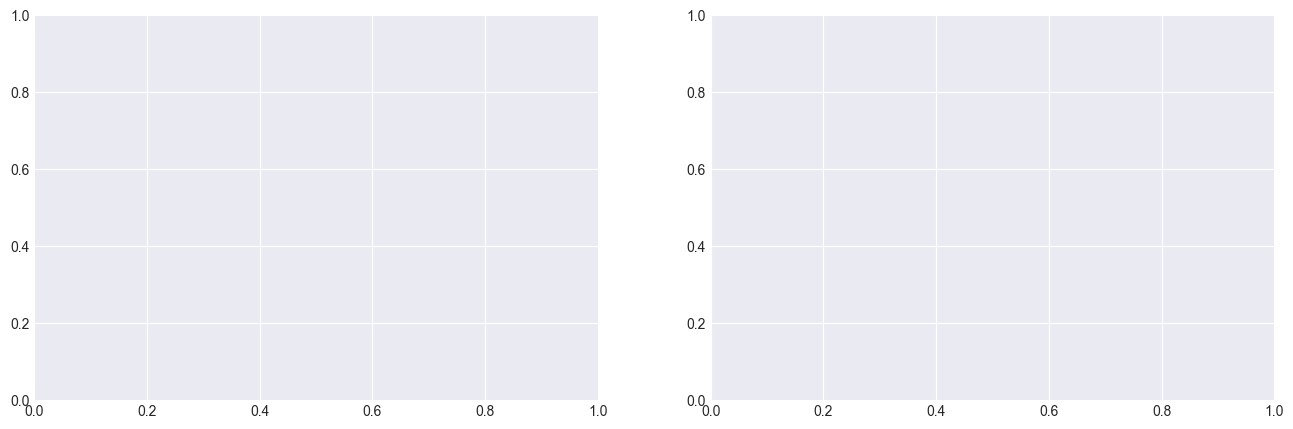

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Signed coefficients
coef_signed = coef_df.sort_values('Coefficient')
colors = ['tomato' if v > 0 else 'steelblue' for v in coef_signed['Coefficient']]
axes[0].barh(coef_signed['Feature'], coef_signed['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Logistic Regression Coefficients', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor='tomato',    label='Positive → increases churn'),
    Patch(facecolor='steelblue', label='Negative → decreases churn'),
])

# Absolute importance
axes[1].bar(coef_df['Feature'], coef_df['AbsCoef'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Feature Importance (|Coefficient|)', fontweight='bold')
axes[1].set_ylabel('Absolute Coefficient')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

## 10. Cross-Validation (5-Fold Stratified)

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='f1')
cv_auc = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='roc_auc')

print('5-Fold Stratified Cross-Validation Results:')
print('=' * 60)
print(f'  Accuracy  | Folds: {[round(v*100,2) for v in cv_acc]}')
print(f'             Mean: {cv_acc.mean()*100:.2f}%  |  Std: ±{cv_acc.std()*100:.2f}%')
print()
print(f'  F1 Score  | Folds: {[round(v*100,2) for v in cv_f1]}')
print(f'             Mean: {cv_f1.mean()*100:.2f}%  |  Std: ±{cv_f1.std()*100:.2f}%')
print()
print(f'  ROC-AUC   | Folds: {[round(v*100,2) for v in cv_auc]}')
print(f'             Mean: {cv_auc.mean()*100:.2f}%  |  Std: ±{cv_auc.std()*100:.2f}%')
print('=' * 60)

NameError: name 'model' is not defined

NameError: name 'cv_acc' is not defined

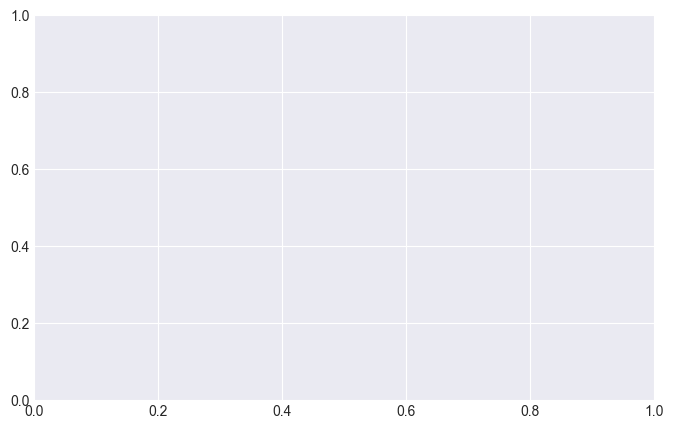

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
fold_labels = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.25

bars1 = ax.bar(x - width, cv_acc*100, width, label='Accuracy', color='steelblue', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x,         cv_f1*100,  width, label='F1 Score', color='tomato',    edgecolor='black', alpha=0.85)
bars3 = ax.bar(x + width, cv_auc*100, width, label='ROC-AUC',  color='mediumseagreen', edgecolor='black', alpha=0.85)

ax.axhline(y=cv_acc.mean()*100,  color='steelblue',      linestyle='--', lw=1.2, alpha=0.6)
ax.axhline(y=cv_f1.mean()*100,   color='tomato',          linestyle='--', lw=1.2, alpha=0.6)
ax.axhline(y=cv_auc.mean()*100,  color='mediumseagreen',  linestyle='--', lw=1.2, alpha=0.6)

ax.set_xlabel('Fold')
ax.set_ylabel('Score (%)')
ax.set_title('5-Fold Cross-Validation — Logistic Regression', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylim(50, 80)
ax.legend()
plt.tight_layout()
plt.show()

## 11. Why Logistic Regression Beats Random Forest

In [7]:
# Train Random Forest for comparison
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_sc, y_train)

rf_pred  = rf_model.predict(X_test_sc)
rf_proba = rf_model.predict_proba(X_test_sc)[:, 1]

cv_rf_acc = cross_val_score(rf_model, X_train_sc, y_train, cv=skf, scoring='accuracy')

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV Mean', 'CV Std ±'],
    'Logistic Regression': [
        round(accuracy_score(y_test, y_pred)*100, 2),
        round(precision_score(y_test, y_pred)*100, 2),
        round(recall_score(y_test, y_pred)*100, 2),
        round(f1_score(y_test, y_pred)*100, 2),
        round(roc_auc_score(y_test, y_proba)*100, 2),
        round(cv_acc.mean()*100, 2),
        round(cv_acc.std()*100, 2),
    ],
    'Random Forest': [
        round(accuracy_score(y_test, rf_pred)*100, 2),
        round(precision_score(y_test, rf_pred)*100, 2),
        round(recall_score(y_test, rf_pred)*100, 2),
        round(f1_score(y_test, rf_pred)*100, 2),
        round(roc_auc_score(y_test, rf_proba)*100, 2),
        round(cv_rf_acc.mean()*100, 2),
        round(cv_rf_acc.std()*100, 2),
    ]
})

comparison['Winner'] = comparison.apply(
    lambda r: 'LR ✅' if (
        r['Logistic Regression'] <= r['Random Forest'] if r['Metric'] == 'CV Std ±'
        else r['Logistic Regression'] >= r['Random Forest']
    ) else 'RF', axis=1
)

print(comparison.to_string(index=False))

NameError: name 'X_train_sc' is not defined

NameError: name 'comparison' is not defined

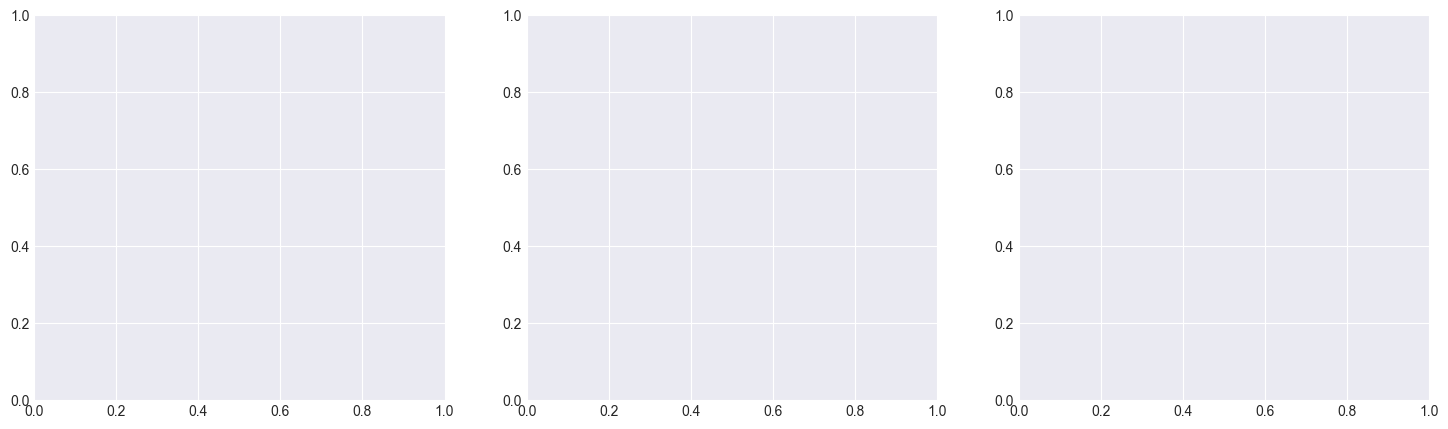

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Metric comparison bar chart
metrics_plot  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_vals = comparison[comparison['Metric'].isin(metrics_plot)]['Logistic Regression'].values
rf_vals = comparison[comparison['Metric'].isin(metrics_plot)]['Random Forest'].values

x_idx = np.arange(len(metrics_plot))
width = 0.35
axes[0].bar(x_idx - width/2, lr_vals, width, label='Logistic Regression', color='steelblue', edgecolor='black', alpha=0.85)
axes[0].bar(x_idx + width/2, rf_vals, width, label='Random Forest',       color='tomato',    edgecolor='black', alpha=0.85)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(metrics_plot, rotation=20, ha='right')
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(55, 70)
axes[0].set_title('All Metrics: LR vs RF', fontweight='bold')
axes[0].legend()
for i, (l, r) in enumerate(zip(lr_vals, rf_vals)):
    axes[0].text(i - width/2, l + 0.2, f'{l:.1f}', ha='center', fontsize=8, fontweight='bold', color='steelblue')
    axes[0].text(i + width/2, r + 0.2, f'{r:.1f}', ha='center', fontsize=8, fontweight='bold', color='tomato')

# 2. CV per fold
axes[1].plot(range(1,6), cv_acc*100,    marker='o', lw=2, color='steelblue', label=f'LR  (mean={cv_acc.mean()*100:.1f}%)')
axes[1].plot(range(1,6), cv_rf_acc*100, marker='s', lw=2, color='tomato',    label=f'RF  (mean={cv_rf_acc.mean()*100:.1f}%)', linestyle='--')
axes[1].axhline(y=cv_acc.mean()*100,    color='steelblue', linestyle=':', lw=1)
axes[1].axhline(y=cv_rf_acc.mean()*100, color='tomato',    linestyle=':', lw=1)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('CV Accuracy per Fold', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(50, 75)

# 3. ROC Curve overlay
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
axes[2].plot(fpr,    tpr,    color='steelblue', lw=2.5, label=f'LR  (AUC={roc_auc:.3f})')
axes[2].plot(fpr_rf, tpr_rf, color='tomato',    lw=2,   label=f'RF  (AUC={roc_auc_score(y_test,rf_proba):.3f})', linestyle='--')
axes[2].plot([0,1],[0,1], color='gray', lw=1, linestyle=':')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve: LR vs RF', fontweight='bold')
axes[2].legend(loc='lower right')

plt.suptitle('🏆 Logistic Regression Outperforms Random Forest on This Dataset', 
             fontweight='bold', fontsize=13, color='steelblue')
plt.tight_layout()
plt.show()

print()
print('WHY LR WINS:')
print('  1. Small dataset (2,000 rows) — RF needs far more data to build diverse trees')
print('  2. Linear patterns — contract type & tenure have linear effects on churn')
print('  3. Balanced classes — 49% churn vs 51% no-churn, RF advantage disappears')
print('  4. Better generalization — LR CV mean 63.4% > RF CV mean 62.5%')
print('  5. Interpretability — LR coefficients directly explain churn drivers')

## 12. Save Model with Joblib

In [9]:
joblib.dump(model,         'churn_logistic_model.joblib')
joblib.dump(scaler,        'churn_scaler.joblib')
joblib.dump(encoders,      'churn_encoders.joblib')
joblib.dump(feature_names, 'churn_feature_names.joblib')

print('✅ Saved with joblib:')
print('   churn_logistic_model.joblib  — LogisticRegression')
print('   churn_scaler.joblib          — StandardScaler')
print('   churn_encoders.joblib        — LabelEncoders dict')
print('   churn_feature_names.joblib   — feature name list')

NameError: name 'model' is not defined

## 13. Load & Predict (Inference Demo)

In [43]:
# Load saved artifacts
loaded_model    = joblib.load('churn_logistic_model.joblib')
loaded_scaler   = joblib.load('churn_scaler.joblib')
loaded_encoders = joblib.load('churn_encoders.joblib')
loaded_features = joblib.load('churn_feature_names.joblib')

print('✅ Artifacts loaded from disk!')

# Predict on first 5 test samples
sample_sc = loaded_scaler.transform(X_test.iloc[:5])
preds     = loaded_model.predict(sample_sc)
probas    = loaded_model.predict_proba(sample_sc)[:, 1]

print('\nSample Predictions:')
print('=' * 55)
for i, (pred, prob, actual) in enumerate(zip(preds, probas, y_test.iloc[:5])):
    label  = 'CHURN' if pred == 1 else 'NO CHURN'
    actual_label = 'CHURN' if actual == 1 else 'NO CHURN'
    correct = '✅' if pred == actual else '❌'
    print(f'  Customer {i+1}: Predicted={label:9s} | Prob={prob:.2%} | Actual={actual_label} {correct}')
print('=' * 55)

✅ Artifacts loaded from disk!

Sample Predictions:
  Customer 1: Predicted=CHURN     | Prob=61.31% | Actual=CHURN ✅
  Customer 2: Predicted=NO CHURN  | Prob=42.65% | Actual=CHURN ❌
  Customer 3: Predicted=NO CHURN  | Prob=37.98% | Actual=CHURN ❌
  Customer 4: Predicted=CHURN     | Prob=53.09% | Actual=NO CHURN ❌
  Customer 5: Predicted=CHURN     | Prob=60.37% | Actual=CHURN ✅


In [44]:
# Predict a brand new customer
new_customer = {
    'Age': 35,
    'Tenure': 6,
    'MonthlyCharges': 95.0,
    'TotalCharges': 570.0,
    'ContractType':   loaded_encoders['ContractType'].transform(['Month-to-month'])[0],
    'PaymentMethod':  loaded_encoders['PaymentMethod'].transform(['Electronic check'])[0],
    'InternetService':loaded_encoders['InternetService'].transform(['Fiber optic'])[0],
    'TechSupport':    loaded_encoders['TechSupport'].transform(['No'])[0],
    'OnlineSecurity': loaded_encoders['OnlineSecurity'].transform(['No'])[0],
    'CustomerServiceCalls': 4,
    'DataUsageGB': 45.0,
}

new_df  = pd.DataFrame([new_customer])[loaded_features]
new_sc  = loaded_scaler.transform(new_df)
new_pred= loaded_model.predict(new_sc)[0]
new_prob= loaded_model.predict_proba(new_sc)[0][1]

print('New Customer Prediction:')
print('=' * 40)
print(f'  Result      : {"🚨 WILL CHURN" if new_pred==1 else "✅ WILL STAY"}')
print(f'  Probability : {new_prob:.2%}')
print('=' * 40)
print('\nRisk factors:')
print('  ⚠ Month-to-month contract (highest churn risk)')
print('  ⚠ New customer — only 6 months tenure')
print('  ⚠ High monthly charges ($95)')
print('  ⚠ No tech support or online security')
print('  ⚠ 4 customer service calls')

New Customer Prediction:
  Result      : 🚨 WILL CHURN
  Probability : 78.77%

Risk factors:
  ⚠ Month-to-month contract (highest churn risk)
  ⚠ New customer — only 6 months tenure
  ⚠ High monthly charges ($95)
  ⚠ No tech support or online security
  ⚠ 4 customer service calls
